In [1]:
#import libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Dataset class to load face images from a directory
class FacesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = [os.path.join(root_dir, f) 
                      for f in os.listdir(root_dir) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img

In [3]:
# Generator network 
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(z_dim, 512), 
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 2048),
            nn.ReLU(True),
            nn.Linear(2048,img_channels * 64 * 64),
            nn.Tanh() 
        )
        
    def forward(self, z):
     img = self.model(z)
     return img.view(z.size(0), 3, 64, 64)

In [4]:
# Discriminator network 
class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
      super().__init__()
        
      self.model = nn.Sequential(
          
        nn.Flatten(),
        nn.Linear(img_channels * 64 * 64, 2048),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Linear(2048, 1024),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Linear(1024, 512),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Linear(512, 1),
        nn.Sigmoid() 
      )
        
    def forward(self, img):
        return self.model(img)
   

In [5]:
# Generate and display sample images from the generator at a given training epoch
def save_generated_images(generator, epoch, device, num_images=9):
    z = torch.randn(num_images, 100, device=device)
    with torch.no_grad():
        imgs = generator(z).cpu()
    grid = torchvision.utils.make_grid(imgs, nrow=3, normalize=True)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"Epoch {epoch}")
    plt.axis('off')
    plt.show()

In [6]:
# Train GAN Network
def train_gan(gen, disc, loader, device, epochs=10, z_dim=100):
    criterion = nn.BCELoss()
    optim_G = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optim_D = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

    for epoch in range(epochs):
        for i, real_imgs in enumerate(loader):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # Labels
            real_lbl = torch.ones(batch_size, 1, device=device)
            fake_lbl = torch.zeros(batch_size, 1, device=device)

            #Train Discriminator
            optim_D.zero_grad()
            loss_real = criterion(disc(real_imgs), real_lbl)
            noise = torch.randn(batch_size, z_dim, device=device)
            fake_imgs = gen(noise).detach()
            loss_fake = criterion(disc(fake_imgs), fake_lbl)
            d_loss = (loss_real + loss_fake) / 2
            d_loss.backward()
            optim_D.step()

            #Train Generator
            optim_G.zero_grad()
            noise = torch.randn(batch_size, z_dim, device=device)
            g_loss = criterion(disc(gen(noise)), real_lbl)
            g_loss.backward()
            optim_G.step()

            if i % 50 == 0:
              print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(loader)}] " f"[D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

        save_generated_images(gen, epoch, device)

Total images: 202599
[Epoch 0/10] [Batch 0/1351] [D loss: 0.7057] [G loss: 0.7032]
[Epoch 0/10] [Batch 50/1351] [D loss: 0.4742] [G loss: 0.6923]
[Epoch 0/10] [Batch 100/1351] [D loss: 0.3332] [G loss: 0.8294]
[Epoch 0/10] [Batch 150/1351] [D loss: 0.4446] [G loss: 0.7369]
[Epoch 0/10] [Batch 200/1351] [D loss: 0.2999] [G loss: 1.3960]
[Epoch 0/10] [Batch 250/1351] [D loss: 0.2639] [G loss: 1.6178]
[Epoch 0/10] [Batch 300/1351] [D loss: 0.0845] [G loss: 2.6836]
[Epoch 0/10] [Batch 350/1351] [D loss: 0.0750] [G loss: 2.3236]
[Epoch 0/10] [Batch 400/1351] [D loss: 0.2343] [G loss: 2.0713]
[Epoch 0/10] [Batch 450/1351] [D loss: 0.3172] [G loss: 1.8390]
[Epoch 0/10] [Batch 500/1351] [D loss: 0.2862] [G loss: 1.9268]
[Epoch 0/10] [Batch 550/1351] [D loss: 0.3084] [G loss: 1.7232]
[Epoch 0/10] [Batch 600/1351] [D loss: 0.2767] [G loss: 1.6703]
[Epoch 0/10] [Batch 650/1351] [D loss: 0.3449] [G loss: 2.0904]
[Epoch 0/10] [Batch 700/1351] [D loss: 0.3839] [G loss: 1.3031]
[Epoch 0/10] [Batch 75

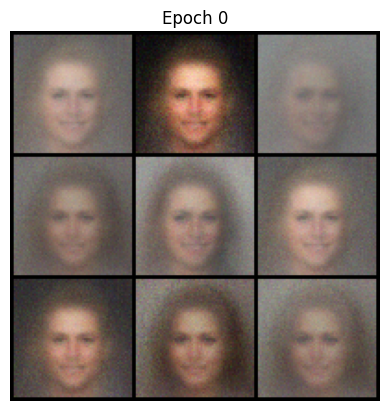

[Epoch 1/10] [Batch 0/1351] [D loss: 0.5076] [G loss: 2.2072]
[Epoch 1/10] [Batch 50/1351] [D loss: 0.3232] [G loss: 2.0250]
[Epoch 1/10] [Batch 100/1351] [D loss: 0.3970] [G loss: 2.1258]
[Epoch 1/10] [Batch 150/1351] [D loss: 0.4470] [G loss: 2.8810]
[Epoch 1/10] [Batch 200/1351] [D loss: 0.3083] [G loss: 2.0013]
[Epoch 1/10] [Batch 250/1351] [D loss: 0.3367] [G loss: 2.7549]
[Epoch 1/10] [Batch 300/1351] [D loss: 0.2448] [G loss: 2.5822]
[Epoch 1/10] [Batch 350/1351] [D loss: 0.3525] [G loss: 1.9651]
[Epoch 1/10] [Batch 400/1351] [D loss: 0.4051] [G loss: 1.8874]
[Epoch 1/10] [Batch 450/1351] [D loss: 0.5777] [G loss: 2.9822]
[Epoch 1/10] [Batch 500/1351] [D loss: 0.3644] [G loss: 3.0557]
[Epoch 1/10] [Batch 550/1351] [D loss: 0.4255] [G loss: 1.7334]
[Epoch 1/10] [Batch 600/1351] [D loss: 0.2752] [G loss: 2.2020]
[Epoch 1/10] [Batch 650/1351] [D loss: 0.4278] [G loss: 1.5849]
[Epoch 1/10] [Batch 700/1351] [D loss: 0.3568] [G loss: 2.5516]
[Epoch 1/10] [Batch 750/1351] [D loss: 0.36

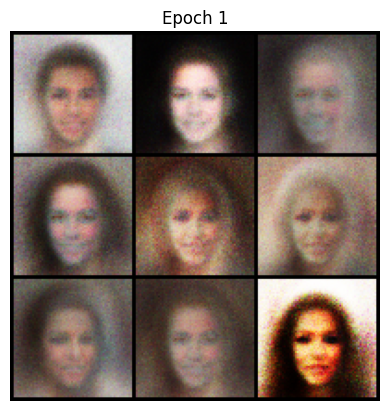

[Epoch 2/10] [Batch 0/1351] [D loss: 0.4755] [G loss: 1.8026]
[Epoch 2/10] [Batch 50/1351] [D loss: 0.4772] [G loss: 2.3080]
[Epoch 2/10] [Batch 100/1351] [D loss: 0.5538] [G loss: 2.9503]
[Epoch 2/10] [Batch 150/1351] [D loss: 0.3812] [G loss: 2.0079]
[Epoch 2/10] [Batch 200/1351] [D loss: 0.4024] [G loss: 1.4469]
[Epoch 2/10] [Batch 250/1351] [D loss: 0.5849] [G loss: 1.8968]
[Epoch 2/10] [Batch 300/1351] [D loss: 0.3863] [G loss: 1.6279]
[Epoch 2/10] [Batch 350/1351] [D loss: 0.3507] [G loss: 2.1620]
[Epoch 2/10] [Batch 400/1351] [D loss: 0.4183] [G loss: 2.3146]
[Epoch 2/10] [Batch 450/1351] [D loss: 0.4394] [G loss: 1.3508]
[Epoch 2/10] [Batch 500/1351] [D loss: 0.4321] [G loss: 1.6003]
[Epoch 2/10] [Batch 550/1351] [D loss: 0.5024] [G loss: 1.5532]
[Epoch 2/10] [Batch 600/1351] [D loss: 0.3924] [G loss: 2.1016]
[Epoch 2/10] [Batch 650/1351] [D loss: 0.4024] [G loss: 1.7611]
[Epoch 2/10] [Batch 700/1351] [D loss: 0.5771] [G loss: 1.6586]
[Epoch 2/10] [Batch 750/1351] [D loss: 0.42

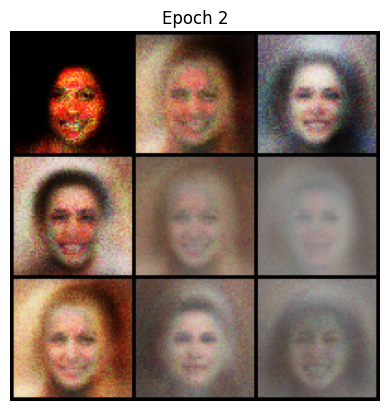

[Epoch 3/10] [Batch 0/1351] [D loss: 0.5173] [G loss: 1.8463]
[Epoch 3/10] [Batch 50/1351] [D loss: 0.5671] [G loss: 1.7518]
[Epoch 3/10] [Batch 100/1351] [D loss: 0.6026] [G loss: 1.8217]
[Epoch 3/10] [Batch 150/1351] [D loss: 0.4915] [G loss: 1.9836]
[Epoch 3/10] [Batch 200/1351] [D loss: 0.5127] [G loss: 2.3162]
[Epoch 3/10] [Batch 250/1351] [D loss: 0.6016] [G loss: 2.6389]
[Epoch 3/10] [Batch 300/1351] [D loss: 0.4515] [G loss: 1.4168]
[Epoch 3/10] [Batch 350/1351] [D loss: 0.5642] [G loss: 1.7954]
[Epoch 3/10] [Batch 400/1351] [D loss: 0.4955] [G loss: 1.8842]
[Epoch 3/10] [Batch 450/1351] [D loss: 0.4917] [G loss: 1.4029]
[Epoch 3/10] [Batch 500/1351] [D loss: 0.4281] [G loss: 1.8009]
[Epoch 3/10] [Batch 550/1351] [D loss: 0.4518] [G loss: 1.6874]
[Epoch 3/10] [Batch 600/1351] [D loss: 0.5979] [G loss: 1.5448]
[Epoch 3/10] [Batch 650/1351] [D loss: 0.5516] [G loss: 1.6865]
[Epoch 3/10] [Batch 700/1351] [D loss: 0.5758] [G loss: 1.5122]
[Epoch 3/10] [Batch 750/1351] [D loss: 0.45

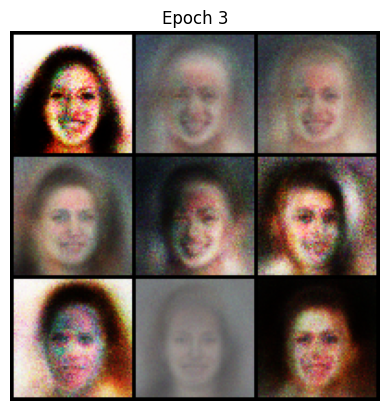

[Epoch 4/10] [Batch 0/1351] [D loss: 0.5980] [G loss: 1.3580]
[Epoch 4/10] [Batch 50/1351] [D loss: 0.5551] [G loss: 1.4299]
[Epoch 4/10] [Batch 100/1351] [D loss: 0.5358] [G loss: 1.3797]
[Epoch 4/10] [Batch 150/1351] [D loss: 0.5457] [G loss: 1.5059]
[Epoch 4/10] [Batch 200/1351] [D loss: 0.5123] [G loss: 1.6904]
[Epoch 4/10] [Batch 250/1351] [D loss: 0.4648] [G loss: 1.7416]
[Epoch 4/10] [Batch 300/1351] [D loss: 0.5651] [G loss: 1.3458]
[Epoch 4/10] [Batch 350/1351] [D loss: 0.4531] [G loss: 1.8671]
[Epoch 4/10] [Batch 400/1351] [D loss: 0.5721] [G loss: 2.0910]
[Epoch 4/10] [Batch 450/1351] [D loss: 0.6393] [G loss: 1.2144]
[Epoch 4/10] [Batch 500/1351] [D loss: 0.5799] [G loss: 1.2135]
[Epoch 4/10] [Batch 550/1351] [D loss: 0.5319] [G loss: 1.4351]
[Epoch 4/10] [Batch 600/1351] [D loss: 0.4932] [G loss: 1.6725]
[Epoch 4/10] [Batch 650/1351] [D loss: 0.4959] [G loss: 1.2609]
[Epoch 4/10] [Batch 700/1351] [D loss: 0.4519] [G loss: 1.5988]
[Epoch 4/10] [Batch 750/1351] [D loss: 0.56

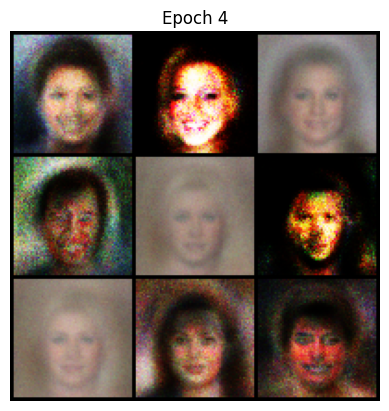

[Epoch 5/10] [Batch 0/1351] [D loss: 0.5957] [G loss: 1.2189]
[Epoch 5/10] [Batch 50/1351] [D loss: 0.5557] [G loss: 1.5064]
[Epoch 5/10] [Batch 100/1351] [D loss: 0.5209] [G loss: 1.4010]
[Epoch 5/10] [Batch 150/1351] [D loss: 0.5376] [G loss: 1.4325]
[Epoch 5/10] [Batch 200/1351] [D loss: 0.5009] [G loss: 1.3707]
[Epoch 5/10] [Batch 250/1351] [D loss: 0.5272] [G loss: 1.2120]
[Epoch 5/10] [Batch 300/1351] [D loss: 0.5407] [G loss: 1.5256]
[Epoch 5/10] [Batch 350/1351] [D loss: 0.5567] [G loss: 1.5575]
[Epoch 5/10] [Batch 400/1351] [D loss: 0.4889] [G loss: 1.7404]
[Epoch 5/10] [Batch 450/1351] [D loss: 0.5490] [G loss: 1.5151]
[Epoch 5/10] [Batch 500/1351] [D loss: 0.5419] [G loss: 1.4490]
[Epoch 5/10] [Batch 550/1351] [D loss: 0.5524] [G loss: 1.4207]
[Epoch 5/10] [Batch 600/1351] [D loss: 0.5337] [G loss: 1.1625]
[Epoch 5/10] [Batch 650/1351] [D loss: 0.6114] [G loss: 1.5842]
[Epoch 5/10] [Batch 700/1351] [D loss: 0.5950] [G loss: 1.5406]
[Epoch 5/10] [Batch 750/1351] [D loss: 0.58

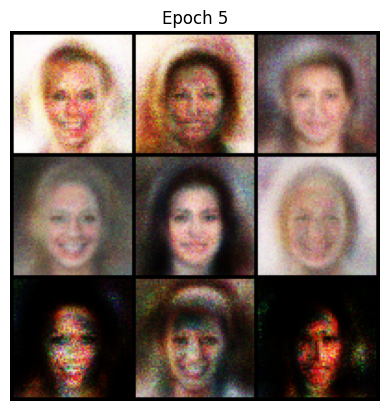

[Epoch 6/10] [Batch 0/1351] [D loss: 0.6019] [G loss: 1.4439]
[Epoch 6/10] [Batch 50/1351] [D loss: 0.5180] [G loss: 1.3988]
[Epoch 6/10] [Batch 100/1351] [D loss: 0.5456] [G loss: 0.9178]
[Epoch 6/10] [Batch 150/1351] [D loss: 0.5658] [G loss: 1.3259]
[Epoch 6/10] [Batch 200/1351] [D loss: 0.5093] [G loss: 1.5466]
[Epoch 6/10] [Batch 250/1351] [D loss: 0.5130] [G loss: 1.1872]
[Epoch 6/10] [Batch 300/1351] [D loss: 0.5252] [G loss: 1.5102]
[Epoch 6/10] [Batch 350/1351] [D loss: 0.4890] [G loss: 1.2149]
[Epoch 6/10] [Batch 400/1351] [D loss: 0.5707] [G loss: 1.3057]
[Epoch 6/10] [Batch 450/1351] [D loss: 0.5211] [G loss: 1.6835]
[Epoch 6/10] [Batch 500/1351] [D loss: 0.5751] [G loss: 1.5124]
[Epoch 6/10] [Batch 550/1351] [D loss: 0.5328] [G loss: 1.3987]
[Epoch 6/10] [Batch 600/1351] [D loss: 0.5620] [G loss: 1.2702]
[Epoch 6/10] [Batch 650/1351] [D loss: 0.5477] [G loss: 1.3245]
[Epoch 6/10] [Batch 700/1351] [D loss: 0.5432] [G loss: 1.5129]
[Epoch 6/10] [Batch 750/1351] [D loss: 0.55

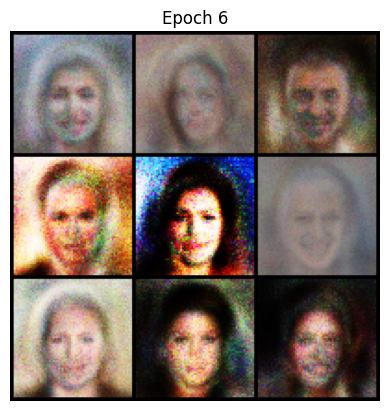

[Epoch 7/10] [Batch 0/1351] [D loss: 0.5624] [G loss: 1.3999]
[Epoch 7/10] [Batch 50/1351] [D loss: 0.5429] [G loss: 1.2391]
[Epoch 7/10] [Batch 100/1351] [D loss: 0.5284] [G loss: 1.2644]
[Epoch 7/10] [Batch 150/1351] [D loss: 0.5986] [G loss: 1.3769]
[Epoch 7/10] [Batch 200/1351] [D loss: 0.5312] [G loss: 1.2863]
[Epoch 7/10] [Batch 250/1351] [D loss: 0.5904] [G loss: 1.2892]
[Epoch 7/10] [Batch 300/1351] [D loss: 0.5200] [G loss: 1.4612]
[Epoch 7/10] [Batch 350/1351] [D loss: 0.5444] [G loss: 1.2258]
[Epoch 7/10] [Batch 400/1351] [D loss: 0.6396] [G loss: 1.1767]
[Epoch 7/10] [Batch 450/1351] [D loss: 0.5460] [G loss: 1.2854]
[Epoch 7/10] [Batch 500/1351] [D loss: 0.5826] [G loss: 1.0990]
[Epoch 7/10] [Batch 550/1351] [D loss: 0.5514] [G loss: 1.2638]
[Epoch 7/10] [Batch 600/1351] [D loss: 0.4991] [G loss: 1.3882]
[Epoch 7/10] [Batch 650/1351] [D loss: 0.5054] [G loss: 1.4050]
[Epoch 7/10] [Batch 700/1351] [D loss: 0.5460] [G loss: 1.3462]
[Epoch 7/10] [Batch 750/1351] [D loss: 0.54

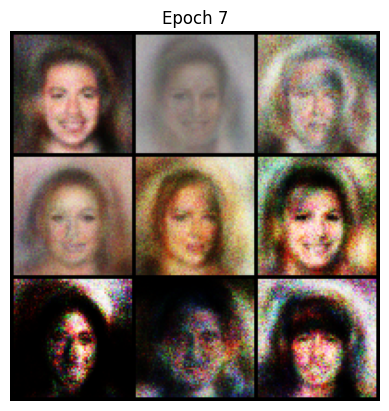

[Epoch 8/10] [Batch 0/1351] [D loss: 0.5322] [G loss: 1.1450]
[Epoch 8/10] [Batch 50/1351] [D loss: 0.5599] [G loss: 1.3438]
[Epoch 8/10] [Batch 100/1351] [D loss: 0.5178] [G loss: 1.3157]
[Epoch 8/10] [Batch 150/1351] [D loss: 0.5740] [G loss: 1.2345]
[Epoch 8/10] [Batch 200/1351] [D loss: 0.6373] [G loss: 1.2429]
[Epoch 8/10] [Batch 250/1351] [D loss: 0.5967] [G loss: 1.1857]
[Epoch 8/10] [Batch 300/1351] [D loss: 0.6165] [G loss: 1.3477]
[Epoch 8/10] [Batch 350/1351] [D loss: 0.6437] [G loss: 1.5328]
[Epoch 8/10] [Batch 400/1351] [D loss: 0.5890] [G loss: 1.3172]
[Epoch 8/10] [Batch 450/1351] [D loss: 0.5555] [G loss: 1.2919]
[Epoch 8/10] [Batch 500/1351] [D loss: 0.5783] [G loss: 1.4909]
[Epoch 8/10] [Batch 550/1351] [D loss: 0.5949] [G loss: 1.2300]
[Epoch 8/10] [Batch 600/1351] [D loss: 0.6185] [G loss: 1.2172]
[Epoch 8/10] [Batch 650/1351] [D loss: 0.5830] [G loss: 1.2217]
[Epoch 8/10] [Batch 700/1351] [D loss: 0.5617] [G loss: 1.2735]
[Epoch 8/10] [Batch 750/1351] [D loss: 0.56

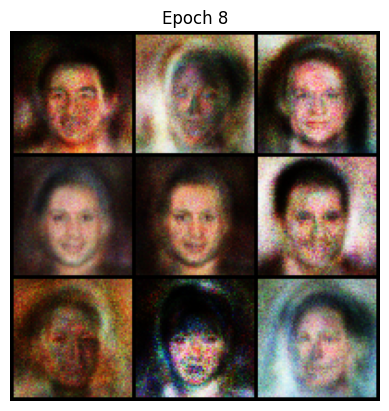

[Epoch 9/10] [Batch 0/1351] [D loss: 0.5596] [G loss: 1.0801]
[Epoch 9/10] [Batch 50/1351] [D loss: 0.5701] [G loss: 1.0330]
[Epoch 9/10] [Batch 100/1351] [D loss: 0.5926] [G loss: 1.5418]
[Epoch 9/10] [Batch 150/1351] [D loss: 0.6082] [G loss: 0.9811]
[Epoch 9/10] [Batch 200/1351] [D loss: 0.5588] [G loss: 1.0667]
[Epoch 9/10] [Batch 250/1351] [D loss: 0.5342] [G loss: 1.2946]
[Epoch 9/10] [Batch 300/1351] [D loss: 0.6081] [G loss: 1.1127]
[Epoch 9/10] [Batch 350/1351] [D loss: 0.6340] [G loss: 1.1638]
[Epoch 9/10] [Batch 400/1351] [D loss: 0.5622] [G loss: 1.0639]
[Epoch 9/10] [Batch 450/1351] [D loss: 0.5614] [G loss: 1.1837]
[Epoch 9/10] [Batch 500/1351] [D loss: 0.5578] [G loss: 1.2755]
[Epoch 9/10] [Batch 550/1351] [D loss: 0.5596] [G loss: 1.1970]
[Epoch 9/10] [Batch 600/1351] [D loss: 0.5709] [G loss: 1.3343]
[Epoch 9/10] [Batch 650/1351] [D loss: 0.6429] [G loss: 1.0060]
[Epoch 9/10] [Batch 700/1351] [D loss: 0.6159] [G loss: 1.1457]
[Epoch 9/10] [Batch 750/1351] [D loss: 0.61

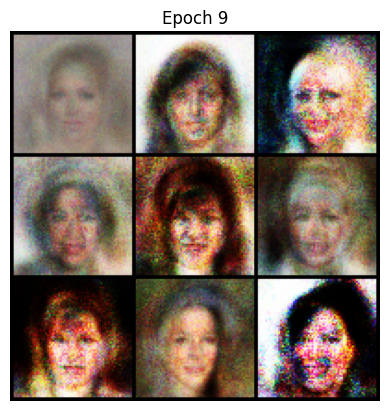

In [7]:
# Main execution: prepare dataset, initialize models, and start GAN training
if __name__ == "__main__":
    dataset_path = '/kaggle/input/img-align-celeba1/img_align_celeba'
    transform = transforms.Compose([
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)])

    dataset = FacesDataset(dataset_path, transform)
    loader = DataLoader(dataset, batch_size=150, shuffle=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    gen = Generator().to(device)
    disc = Discriminator().to(device)

    print(f"Total images: {len(dataset)}")
    train_gan(gen, disc, loader, device, epochs=10)
